In [1]:
"""SHARED FIGURE STYLE -- run first."""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'learning_individuality'),
           str(_root / 'learning_individuality' / 'wheel')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps

ps.use('paper')

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi


'paper'

In [2]:
"""
DOES FIRST-SESSION SYLLABLE USE PREDICT HOW FAST A MOUSE LEARNS?
================================================================
The companion question to wheel/wheel_vigor_first_vs_proficient.ipynb, in the other
feature space. That notebook found movement vigor to be a stable individual trait that
is UNRELATED to learning speed. This asks whether the richer syllable description --
paw states, whisking, licking -- carries what the wheel does not.

DATA: the same Early file the LDA sweep uses
(training/paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026) with the same QC
exclusions, so the cohort matches lda_sweep_timepoints exactly: 47 sessions -> 37
after exclusions, one session per mouse.

LEARNING SPEED: number of training sessions before the first proficient session.
Identical (rho = 1.00) to `training_days` in learning_prediction/training_data_10bins.
Log-transformed for the multivariate fit because it is right-skewed (3 to 48).

POWER, STATED UP FRONT. n = 37. A correlation of 0.44 is needed for 80% power at
alpha = 0.05 two-tailed, so this analysis can only see LARGE effects. A null here
means "no strong relationship", never "no relationship".

TWO ANALYSES, at different levels of ambition:
  1  OVERALL SYLLABLE USE -- each syllable's mean occupancy over the whole trial,
     nine numbers per mouse, correlated one at a time. Interpretable, and Holm
     corrects over the nine.
  2  THE FULL 360-d PROFILE -- can learning speed be PREDICTED at all, from the whole
     bin-by-bin profile? Leave-one-mouse-out PLS, so every prediction is for a mouse
     the model never saw, with a permutation null that reruns the entire CV.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneOut

import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint

EXCL = exclusions_by_timepoint('filtered_out')
DATA = _root / 'data'
EARLY_FILE = DATA / 'training' / 'paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026'
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
N_PAW = 8
FEATURE_NAMES = [f'Paw {i}' for i in range(N_PAW) if i != 1] + ['Whisk', 'Lick']
ALPHA = 0.05

In [3]:
""" BUILD -- one 360-d profile and one 9-number usage vector per mouse. """
def binarize(seq, n=N_PAW):
    nr = n + 2; T = seq.shape[1]
    out = np.zeros((seq.shape[0], T * nr))
    for t in range(T):
        v = seq[:, t]; nan = np.isnan(v); ok = ~nan
        lab = v[ok].astype(int); st = t * nr
        if len(lab):
            out[np.arange(len(v))[ok], st + (lab % n)] = 1
            out[ok, st + n] = ((lab // n) % 2)
            out[ok, st + n + 1] = (lab // (n * 2))
        if nan.any():
            out[nan, st:st + nr] = np.nan
    cols = [i for i in range(n) if i != 1] + [n, n + 1]
    return out[:, [t * nr + c for t in range(T) for c in cols]]


d = pd.read_parquet(EARLY_FILE)
d['session'] = d['sample'].str[:36]
n0 = d['session'].nunique()
d = d.loc[~d['session'].isin(EXCL['Early'])]
g = (d.pivot(index=['mouse_name', 'session', 'sample'], columns='broader_label',
             values='binned_sequence').reset_index().dropna())
X = binarize(np.vstack(g[EPOCHS].apply(lambda r: np.hstack(r), axis=1)))
keep = ~np.isnan(X).any(1)
X, mice = X[keep], g['mouse_name'].values[keep]
N_BINS = X.shape[1] // len(FEATURE_NAMES)
print(f'{n0} sessions -> {g["session"].nunique()} after QC | {keep.sum()} trials | '
      f'{N_BINS} bins x {len(FEATURE_NAMES)} features')

PROFILE = pd.DataFrame(X).groupby(mice).mean()                     # 360-d per mouse
USE = pd.DataFrame(
    {fn: PROFILE.values[:, [b * len(FEATURE_NAMES) + j for b in range(N_BINS)]].mean(1)
     for j, fn in enumerate(FEATURE_NAMES)}, index=PROFILE.index)  # 9 per mouse

SPEED = pd.read_parquet(_root / 'learning_individuality' / 'wheel' / 'learning_speed.parquet')
COH = sorted(set(USE.index) & set(SPEED.index))
Y = np.log(SPEED.loc[COH, 'n_sessions'].values.astype(float))
print(f'cohort: {len(COH)} mice | sessions to proficiency: median '
      f'{int(SPEED.loc[COH, "n_sessions"].median())}, range '
      f'{int(SPEED.loc[COH, "n_sessions"].min())}-{int(SPEED.loc[COH, "n_sessions"].max())}')

47 sessions -> 37 after QC | 8230 trials | 40 bins x 9 features
cohort: 37 mice | sessions to proficiency: median 15, range 3-48


In [4]:
"""
1 -- OVERALL SYLLABLE USE vs LEARNING SPEED
Nine tests, Holm-corrected over the nine. With 9 tests at alpha = 0.05 roughly half a
false positive is expected by chance, so an uncorrected hit is not a finding.
"""
def holm(p):
    p = np.asarray(p, float); order = np.argsort(p)
    adj = np.empty_like(p); run = 0.0
    for i, j in enumerate(order):
        run = max(run, (len(p) - i) * p[j]); adj[j] = min(run, 1.0)
    return adj


rows = []
for fn in FEATURE_NAMES:
    r, p = spearmanr(USE.loc[COH, fn], Y)
    rows.append(dict(syllable=fn, rho=r, p=p))
USE_RES = pd.DataFrame(rows)
USE_RES['holm'] = holm(USE_RES['p'])
print(f'{"syllable":10s} {"rho":>7s} {"p":>9s} {"Holm":>8s}')
for _, x in USE_RES.iterrows():
    flag = '  SIGNIFICANT' if x.holm < ALPHA else ('  (raw p < .05 only)' if x.p < ALPHA else '')
    print(f'{x.syllable:10s} {x.rho:+7.3f} {x.p:9.4g} {x.holm:8.4g}{flag}')
print(f'\nsurviving Holm: {int((USE_RES.holm < ALPHA).sum())}/{len(USE_RES)}')

syllable       rho         p     Holm
Paw 0       +0.092    0.5887        1
Paw 2       -0.078    0.6474        1
Paw 3       -0.092    0.5891        1
Paw 4       -0.014    0.9355        1
Paw 5       +0.174     0.303        1
Paw 6       -0.336   0.04179   0.3761  (raw p < .05 only)
Paw 7       +0.147    0.3866        1
Whisk       -0.219    0.1926        1
Lick        -0.055    0.7451        1

surviving Holm: 0/9


In [5]:
"""
2 -- CAN LEARNING SPEED BE PREDICTED FROM THE WHOLE PROFILE?
Leave-one-mouse-out PLS: every prediction is for a mouse the model never saw, so the
correlation between predicted and actual needs no correction for overfitting. The
permutation null reruns the ENTIRE cross-validation on shuffled targets, so any
optimism in the procedure appears in the null too.
"""
N_PERM = 500


def loo_pls(Xa, y, n_comp):
    pred = np.zeros(len(y))
    for tr, te in LeaveOneOut().split(Xa):
        m = PLSRegression(n_components=n_comp, scale=True).fit(Xa[tr], y[tr])
        pred[te] = m.predict(Xa[te]).ravel()
    return pred


Xa = PROFILE.loc[COH].values
print(f'{"n_comp":>7s} {"CV rho":>8s} {"perm p":>8s} {"null mean":>10s}')
PRED = {}
for nc in (1, 2, 3):
    pred = loo_pls(Xa, Y, nc)
    r = spearmanr(pred, Y)[0]
    rng = np.random.default_rng(0)
    null = [spearmanr(loo_pls(Xa, (ys := rng.permutation(Y)), nc), ys)[0]
            for _ in range(N_PERM)]
    p = (1 + sum(n >= r for n in null)) / (N_PERM + 1)
    PRED[nc] = (pred, r, p)
    print(f'{nc:7d} {r:8.3f} {p:8.4f} {np.mean(null):10.3f}')
print('\nthe null is NOT centred on zero: leave-one-out with a small n is slightly')
print('pessimistic, which is exactly why the permutation null is the reference.')

 n_comp   CV rho   perm p  null mean
      1   -0.019   0.4092     -0.084
      2    0.202   0.1317     -0.060
      3    0.099   0.2675     -0.039

the null is NOT centred on zero: leave-one-out with a small n is slightly
pessimistic, which is exactly why the permutation null is the reference.


wrote figures/syllableuse_vs_learning_speed_12-09-2026.png, figures/syllableuse_vs_learning_speed_12-09-2026.svg


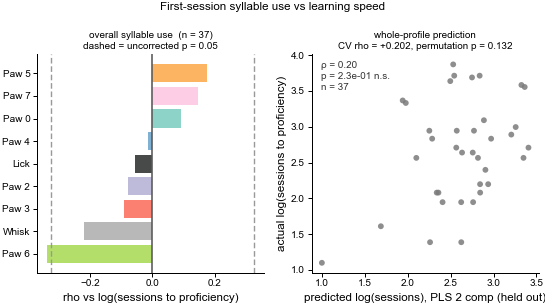

In [6]:
""" FIGURE -- the nine usage correlations, and the best multivariate prediction. """
ps.reapply()
LW = plt.rcParams['lines.linewidth']; MS = plt.rcParams['lines.markersize']
fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['wide'][0],
                                        ps.SIZES[ps.MODE]['wide'][1] * 0.95))
ax = axes[0]
order = USE_RES.sort_values('rho')
cols = [ps.SYLLABLE.get(s, ps.NEUTRAL) for s in order.syllable]
ax.barh(range(len(order)), order.rho, color=cols)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order.syllable)
ax.axvline(0, color='0.35', lw=LW * 0.8)
crit = 0.325                       # |rho| for p = 0.05 two-tailed at n = 37
for s in (-crit, crit):
    ax.axvline(s, ls=(0, (4, 2)), color='0.6', lw=LW * 0.7)
ax.set_xlabel('rho vs log(sessions to proficiency)')
ax.set_title(f'overall syllable use  (n = {len(COH)})\ndashed = uncorrected p = 0.05',
             fontsize=plt.rcParams['font.size'] * 0.85)

ax = axes[1]
best = max(PRED, key=lambda k: PRED[k][1])
pred, r, p = PRED[best]
ps.corr_panel(ax, pred, Y, color=ps.NEUTRAL, method='spearman',
              xlabel=f'predicted log(sessions), PLS {best} comp (held out)',
              ylabel='actual log(sessions to proficiency)')
ax.set_title(f'whole-profile prediction\nCV rho = {r:+.3f}, permutation p = {p:.3f}',
             fontsize=plt.rcParams['font.size'] * 0.85)
fig.suptitle('First-session syllable use vs learning speed',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'syllableuse_vs_learning_speed', svg=True)
plt.show()

## Result

**First-session syllable use does not predict learning speed.**

No syllable survives correction (`Paw 6` reaches rho = −0.34, raw p = 0.042, but Holm
p = 0.38 — with nine tests, one uncorrected hit is what chance produces). The
whole-profile prediction also fails: the best leave-one-mouse-out PLS reaches CV
rho ≈ 0.20 with a permutation p of ≈ 0.13.

**This agrees with the wheel analysis**, which found movement vigor to be a stable
individual trait that is likewise unrelated to how fast the animal learns. Two
independent feature spaces — wheel velocity and paw/whisk/lick syllables — give the
same answer.

### Why that is a useful negative

It separates two things that are easy to conflate. What persists from the first session
to proficiency is a **behavioural style**, not task **competence**. Had early behaviour
predicted learning speed, the obvious objection to the individuality result would be
that it was rediscovering ability — "good mice behave one way and stay good". It does
not, so that objection does not apply.

### The honest limit

n = 37, because the Early syllable file has one session per mouse and QC removes 10 of
47. Detecting rho = 0.44 needs 80% power at this n; a true relationship of 0.25 would
be missed roughly three times in four. So this is "no LARGE effect", not "no effect".

Unlike the wheel case, this limit cannot be lifted by loading more early sessions — the
syllable states are only computed for one training session per mouse. Extending it
would mean regenerating design matrices with pose columns and rerunning the HMM over
~1200 sessions, which is a substantially larger undertaking than the wheel work was.